In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder 

import numpy as np

import sys
sys.path.append('../Code')
from sklearn import metrics
from CustomTransformers import CollinearityDropper

La varianza como medida de dispersion no da una idea de lo distribuido que estan los datos. En el caso extremo una constante con varianza=0 no tendrá poder predictivo. A medida aumenta la dispersion de los datos podemos suponer (muy ingenuamente) que aumenta la capacidad predictiva (Valores hash/identificadores únicos random tendran una varianza importante y nula capacidad predictiva)

In [11]:
df = pd.read_csv('../datasets/metro_interstate_traffic_volume_preprocessed.csv')

In [12]:
# Calcular varianza y desvío estándar (solo columnas numéricas)
cols_numericas = df[df.drop(columns=["traffic_volume"]).columns.tolist()].select_dtypes(include=np.number).columns

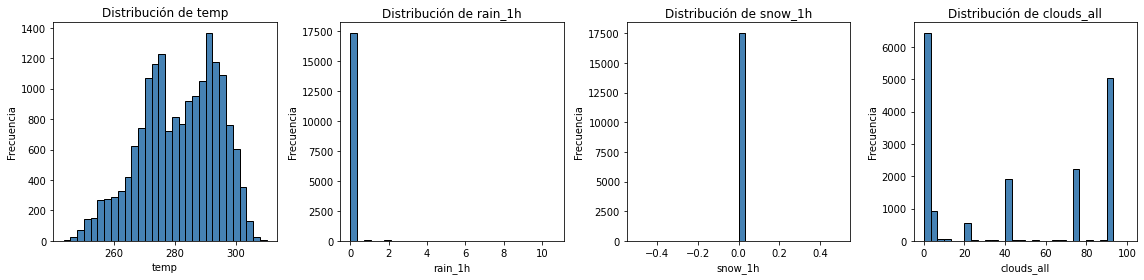

In [13]:
fig, axes = plt.subplots(1, len(cols_numericas), figsize=(16, 4))

for i, col in enumerate(cols_numericas):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

               varianza  desvio_estandar
temp         160.991986        12.688262
rain_1h        0.067493         0.259794
snow_1h        0.000000         0.000000
clouds_all  1526.149206        39.065960


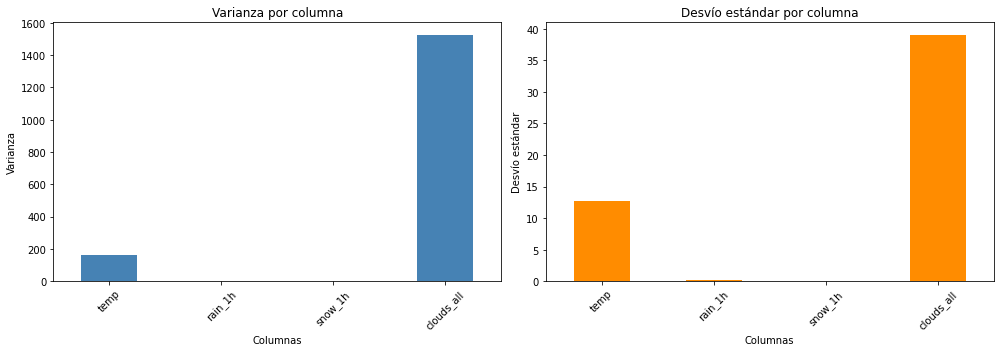

In [14]:

estadisticas = df[cols_numericas].agg(['var', 'std']).T
estadisticas.columns = ['varianza', 'desvio_estandar']

print(estadisticas)

# Graficar con barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

estadisticas['varianza'].plot(kind='bar', ax=axes[0], color='steelblue', title='Varianza por columna')
axes[0].set_xlabel('Columnas')
axes[0].set_ylabel('Varianza')
axes[0].tick_params(axis='x', rotation=45)

estadisticas['desvio_estandar'].plot(kind='bar', ax=axes[1], color='darkorange', title='Desvío estándar por columna')
axes[1].set_xlabel('Columnas')
axes[1].set_ylabel('Desvío estándar')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

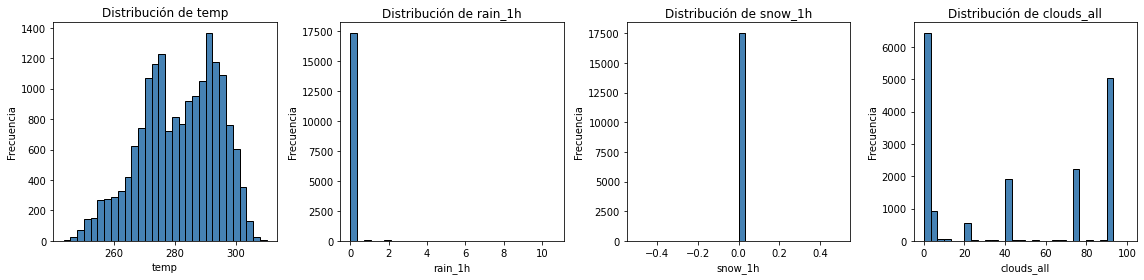

No queremos fuga de datos, separamos en entrenamiento y test, el análisis de varianza se hace solo sobre entrenamiento. 

In [19]:
X = df.drop(columns=["traffic_volume"])
y = df["traffic_volume"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_selection import VarianceThreshold
# Crear el selector de varianza con un umbral (por ejemplo, 0.1)
vtselector = VarianceThreshold(threshold=0.1)
# Ajustar el selector a los datos (excluyendo la variable objetivo)
vtselector.fit(X_train[cols_numericas])
vtselector.transform(X_train[cols_numericas])  # Transformar los datos de entrenamiento



array([[270.15,   5.  ],
       [290.05,  90.  ],
       [261.08,   1.  ],
       ...,
       [278.59,  20.  ],
       [290.48,   1.  ],
       [292.22,  90.  ]])

Quedaron solo dos columnas ¿Que pasó?

In [22]:
vtselector.get_feature_names_out(cols_numericas)

array(['temp', 'clouds_all'], dtype=object)

Las dos columnas que quedaron son las que esperabamos...temp y clouds_all. Eso si, perdimos los nombre ya entraremos en detalle con esto.

Fantástico, pero...la varianza es dependiente de la escala de los datos. Un umbral de 0.1 puede ser mucho o poco. ¿porque no usa el desvío? Por un tema de costo computacional. Dependiendo de nuestro objetivo es posible que tengamos que escalar previamente los datos.

Si queremos por ejemplo, eliminar el 5% de las columnas con menor variabilidad entonces habra que escalar (MinMaxScaler), calcular las varianzas, que ahora si están en igual escala, identificar el umbral que abarca el 10% y luego ejecutar VarianceThreshold.

In [6]:
vals = np.array([25,25,25,26,26,24,24,25,25,25])

In [7]:
np.var(vals)

0.4

In [9]:
np.var(np.array([0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1]))

0.25

In [2]:
vals = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
np.var(vals)

18.666666666666668

"El contra" Veamos un contra ejemplo que nos ayude a enteder que esto no es siempre cierto.

In [27]:
ds = np.array([[1,0,0,0,0,0,0,0,0],
               [0,1,0,0,0,0,0,0,0],
               [0,0,1,0,0,0,0,0,0],
               [0,0,0,1,0,0,0,0,0],
               [0,0,0,0,1,0,0,0,1],
               [0,0,0,0,0,1,0,0,1],
               [0,0,0,0,0,0,1,0,1],
               [0,0,0,0,0,0,0,1,1],

               [1,0,0,0,0,0,0,0,0],
               [0,1,0,0,0,0,0,0,0],
               [0,0,1,0,0,0,0,0,0],
               [0,0,0,1,0,0,0,0,0],
               [0,0,0,0,1,0,0,0,1],
               [0,0,0,0,0,1,0,0,1],
               [0,0,0,0,0,0,1,0,1],
               [0,0,0,0,0,0,0,1,1],

               [1,0,0,0,0,0,0,0,0],
               [0,1,0,0,0,0,0,0,0],
               [0,0,1,0,0,0,0,0,0],
               [0,0,0,1,0,0,0,0,0],
               [0,0,0,0,1,0,0,0,1],
               [0,0,0,0,0,1,0,0,1],
               [0,0,0,0,0,0,1,0,1],
               [0,0,0,0,0,0,0,1,1]
               ])

df = pd.DataFrame(ds, columns=["f1", "f2", "f3", "f4", "f5", "f6", "f7", "f8", "target"])
np.var(df["f1"])

0.109375

In [28]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["target"]), df["target"], test_size=0.2, random_state=42)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 1.0


A pesar de tener una varianza pequeña resultan importantes estas variables para realizar una buena predicción. Funcionan bien en conjunto. ¿Son candidatas a un proceso de feature engineering? Probablemente se puedan compactar en una única variable, pero eso es otro tema.
